# Часть 2: Исследовательский анализ данных в Python и проверка гипотез

### Цели
Провести исследовательский анализ данных в Python, чтобы выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

### Описание данных
В вашем распоряжении снова будут данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 30 октября 2024 года. Их вы уже использовали в предыдущей части проекта. Для удобства работы с данными на платформе в тетради Jupyter Notebook мы подготовили два датасета final_tickets_orders_df.csv и final_tickets_events_df.csv.

### Задачи
Шаг 1. Загрузка данных и знакомство с ними<br>
Шаг 2. Предобработка данных и подготовка их к исследованию<br>
Шаг 3. Исследовательский анализ данных<br>
3.1. Анализ распределения заказов по сегментам и их сезонные изменения<br>
3.2. Осенняя активность пользователей<br>
3.3. Популярные события и партнёры<br>
Шаг 4. Статистический анализ данных<br>
Шаг 5. Общий вывод и рекомендации<br>

### Шаг 1. Загрузка данных и знакомство с ними
Загрузите данные и получите первую информацию о них. Оцените объём данных, их корректность и соответствие описанию, а также предположите, какие шаги необходимо сделать на стадии предобработки данных. Основные моменты зафиксируйте в промежуточном выводе.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
display(orders_df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [3]:
events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
display(events_df.head())

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [4]:
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
display(tenge_df.head())

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [5]:
print("Информация о orders_df:")
orders_df.info()

Информация о orders_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3

In [6]:
print("\nИнформация о events_df:")
events_df.info()


Информация о events_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [7]:
print("\nИнформация о tenge_df:")
tenge_df.info()


Информация о tenge_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


**Промежуточный вывод:**

В orders_df есть пропуски в days_since_prev 

Валюты: RUB (рубли) и KZT (тенге). Конвертация через tenge_df потребуется.

В events_df нет явных пропусков, но нужно проверить уникальность event_id

### Шаг 2. Предобработка данных и подготовка их к исследованию

Проведите предобработку данных:<br>
Проверьте данные на пропуски. Проверьте, что выгрузка данных из SQL была успешной. Кроме столбца days_since_prev, данные не должны содержать пропусков.<br>
Изучите значения в ключевых столбцах и при обнаружении ошибок обработайте их.<br>
Для категориальных значений изучите, какие категории присутствуют в данных. Проверьте, встречаются ли значения, которые могут обозначать пропуски в данных или отсутствие информации. Проведите нормализацию данных, если это необходимо.<br>
Для количественных значений посмотрите на распределение и наличие выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха. Для анализа данных важными показателями являются выручка с заказа revenue и количество билетов в заказе tickets_count, поэтому в первую очередь проверьте данные в этих столбцах. Если найдутся выбросы в выручке с заказа revenue, то отберите значения по 99-му процентилю. Не забудьте, что данные изначально были представлены в разных валютах, поэтому разделите анализ на рубли и тенге.<br>
Проверьте явные и неявные дубликаты. Сделайте акцент на неявных дубликатах по бронированию билета без учёта идентификаторов заказа и, если такие будут, примите обоснованное решение, как их стоит обработать.<br>
Проведите преобразования типов данных. Обратите внимание на типы данных с датой и временем, а также проверьте возможность снижения размерности количественных данных.<br>
Создайте несколько новых столбцов:<br>
revenue_rub — приведите выручку с заказа к единой валюте — российскому рублю. Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю final_tickets_tenge_df.csv за 2024 год. Значения в рублях представлены для 100 тенге.<br>
one_ticket_revenue_rub — рассчитайте выручку с продажи одного билета на мероприятие.<br><br>
month — выделите месяц оформления заказа в отдельный столбец.<br>
season — создайте столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.<br>
Рекомендация: вначале можно объединить данные в один датафрейм, а затем провести общую предобработку.<br>
После предобработки проверьте, сколько данных вы отобрали, если выполняли фильтрацию, а также дайте промежуточный вывод с основными действиями и описанием новых столбцов.<br>

<b>Проверка пропусков:

In [8]:
print("Пропуски в orders_df:")
display(orders_df.isna().sum())

print("\nПропуски в events_df:")
display(events_df.isna().sum())

Пропуски в orders_df:


order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64


Пропуски в events_df:


event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

<b>Анализ категориальных переменных:

<b>Уникальные категории:

In [9]:
cat_cols = ['cinema_circuit', 'age_limit', 'device_type_canonical', 'service_name']
for col in cat_cols:
    print(f"\nУникальные значения в {col}:")
    display(orders_df[col].value_counts())


Уникальные значения в cinema_circuit:


нет           289451
Другое          1261
КиноСити         122
Москино            7
Киномакс           7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64


Уникальные значения в age_limit:


16    78579
12    62557
0     61487
6     52173
18    36053
Name: age_limit, dtype: int64


Уникальные значения в device_type_canonical:


mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64


Уникальные значения в service_name:


Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                   67
Цвет и б

<b>Нормализация категорий:

In [10]:
orders_df['device_type_canonical'] = orders_df['device_type_canonical'].str.lower().replace({'desctop': 'desktop'})

<b>Анализ количественных переменных:

<b>Распределение и выбросы:

Описательная статистика:


,revenue,tickets_count,total
count,290849.000000,290849.000000,290849.000000
mean,625.083054,2.754230,7526.465613
std,1227.316214,1.170467,15328.267730
min,-90.760000,1.000000,-358.850000
25%,116.790000,2.000000,2156.870000
50%,355.340000,3.000000,4771.390000
75%,809.750000,4.000000,8955.950000
max,81174.540000,57.000000,811745.400000


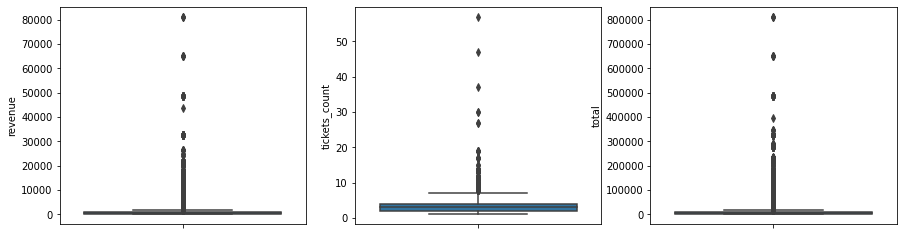

In [11]:
num_cols = ['revenue', 'tickets_count', 'total']
print("Описательная статистика:")
display(orders_df[num_cols].describe())

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(data=orders_df, y=col, ax=axes[i])
plt.show()

<b>Для revenue и total отфильтруем 99-й процентиль:

In [12]:
revenue_threshold = orders_df['revenue'].quantile(0.99)
orders_df = orders_df[orders_df['revenue'] <= revenue_threshold]

<b>Анализ по валютам:

In [13]:
print("Распределение revenue по валютам:")
display(orders_df.groupby('currency_code')['revenue'].describe())

Распределение revenue по валютам:


,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,2732.0,1378.669220,1362.974125,0.00,277.71,578.63,2318.56,3997.70
rub,285210.0,529.589362,544.707744,-90.76,113.34,345.12,788.90,4000.19


<b>Поиск дубликатов

<b>Явные дубликаты:

In [14]:
print("Явные дубликаты в orders_df:", orders_df.duplicated().sum())

Явные дубликаты в orders_df: 0


<b>Неявные дубликаты:

In [15]:
duplicates = orders_df.duplicated(subset=['user_id', 'event_id', 'created_dt_msk'], keep=False)
print("\nНеявные дубликаты:", duplicates.sum())
display(orders_df[duplicates].sort_values(['user_id', 'event_id']))


Неявные дубликаты: 142639


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12,rub,mobile,1421.91,Лови билет!,4,17773.87,NaN
10,6818133,000cf0659a9f40f,2024-06-20,2024-06-20 12:47:22,516728,нет,12,rub,mobile,1066.43,Лови билет!,3,13330.40,0.0
11,6818249,000cf0659a9f40f,2024-06-20,2024-06-20 10:49:48,516728,нет,12,rub,mobile,710.95,Лови билет!,2,8886.94,0.0
12,6818220,000cf0659a9f40f,2024-06-20,2024-06-20 10:56:16,516728,нет,12,rub,mobile,1421.91,Лови билет!,4,17773.87,0.0
13,6818075,000cf0659a9f40f,2024-06-20,2024-06-20 12:42:12,516728,нет,12,rub,mobile,1421.91,Лови билет!,4,17773.87,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290816,3260210,fffcd3dde79eb2c,2024-08-04,2024-08-04 11:29:36,554265,нет,0,rub,mobile,213.81,Лучшие билеты,3,3054.36,0.0
290817,3260036,fffcd3dde79eb2c,2024-08-04,2024-08-04 11:16:39,554265,нет,0,rub,mobile,213.81,Лучшие билеты,3,3054.36,0.0
290818,3260181,fffcd3dde79eb2c,2024-08-04,2024-08-04 11:12:41,554265,нет,0,rub,mobile,213.81,Лучшие билеты,3,3054.36,0.0
290819,3260007,fffcd3dde79eb2c,2024-08-04,2024-08-04 11:25:14,554265,нет,0,rub,mobile,213.81,Лучшие билеты,3,3054.36,0.0


<b>Удаляем дубликаты, оставив последний заказ

In [16]:
orders_df = orders_df.drop_duplicates(subset=['user_id', 'event_id', 'created_dt_msk'], keep='last')

<b>Преобразование типов данных:

In [17]:
# Даты
orders_df['created_dt_msk'] = pd.to_datetime(orders_df['created_dt_msk']) 

# Оптимизация числовых типов
orders_df['tickets_count'] = orders_df['tickets_count'].astype('int8')

<b>Создание новых столбцов:

<b>Конвертация валют

In [18]:
# Переименуем столбец с датой в tenge_df для удобства
tenge_df = tenge_df.rename(columns={'data': 'date'})
tenge_df['date'] = pd.to_datetime(tenge_df['date'])

# Добавим курс RUB/KZT в orders_df (100 KZT = X RUB)
orders_df['created_dt_msk'] = pd.to_datetime(orders_df['created_dt_msk'])
orders_df = orders_df.merge(
    tenge_df[['date', 'curs']],
    left_on=orders_df['created_dt_msk'].dt.date,
    right_on=tenge_df['date'].dt.date,
    how='left'
)

# Конвертируем KZT в RUB (total и revenue)
orders_df['total_rub'] = np.where(
    orders_df['currency_code'] == 'KZT',
    orders_df['total'] * orders_df['curs'] / 100,  # 100 KZT = X RUB
    orders_df['total']
)
orders_df['revenue_rub'] = np.where(
    orders_df['currency_code'] == 'KZT',
    orders_df['revenue'] * orders_df['curs'] / 100,
    orders_df['revenue']
)

<b>Выручка за 1 билет

In [19]:
orders_df['one_ticket_revenue_rub'] = orders_df['revenue_rub'] / orders_df['tickets_count']

<b>Месяц и сезон:

In [20]:
orders_df['month'] = orders_df['created_dt_msk'].dt.month
season_map = {
    1: 'зима', 2: 'зима', 3: 'весна', 
    4: 'весна', 5: 'весна', 6: 'лето',
    7: 'лето', 8: 'лето', 9: 'осень',
    10: 'осень', 11: 'осень', 12: 'зима'
}
orders_df['season'] = orders_df['month'].map(season_map)

In [21]:
# Удаляем временные столбцы
orders_df = orders_df.drop(columns=['key_0', 'curs'], errors='ignore')

# Объединяем с events_df
df = orders_df.merge(events_df, on='event_id', how='left')
print("Итоговый размер данных:", df.shape)

Итоговый размер данных: (190297, 30)


**Промежуточный вывод:**<br>
    
Пропуски нашлись только в столбце days_since_prev, остальные данные целые<br>

Выбросы в выручке (слишком дорогие заказы) убрали — оставили только 99% самых типичных значений<br>

Дубликаты проверили: явные удалили, а повторяющиеся заказы (например, от одного пользователя на одно мероприятие) оставили только последние<br>

Добавили новые столбцы: перевели все деньги в рубли, посчитали стоимость одного билета и выделили месяц/сезон каждого заказа   


### Шаг 3. Исследовательский анализ данных
 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

 <b>Общая динамика заказов по месяцам:

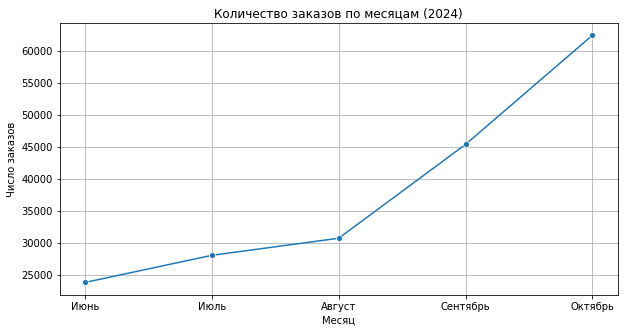

In [22]:
# Группировка по месяцам
monthly_orders = df.groupby('month')['order_id'].count().reset_index()

# Визуализация
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_orders, x='month', y='order_id', marker='o')
plt.title('Количество заказов по месяцам (2024)')
plt.xlabel('Месяц')
plt.ylabel('Число заказов')
plt.xticks(range(6, 11), ['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь'])
plt.grid()
plt.show()

<b>Сравнение лета и осени по категориям:

<b>Распределение по типам мероприятий:

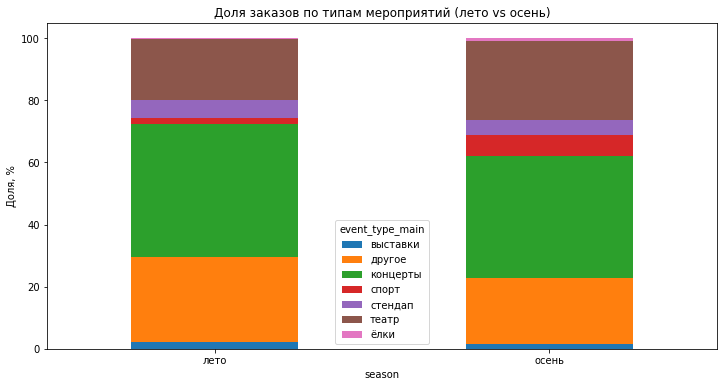

In [23]:
# Доли заказов по event_type_main
season_comparison = df.groupby(['season', 'event_type_main'])['order_id'].count().unstack()
season_comparison = season_comparison.div(season_comparison.sum(axis=1), axis=0) * 100

# Визуализация
season_comparison.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Доля заказов по типам мероприятий (лето vs осень)')
plt.ylabel('Доля, %')
plt.xticks(rotation=0)
plt.show()

<b>Распределение по устройствам:

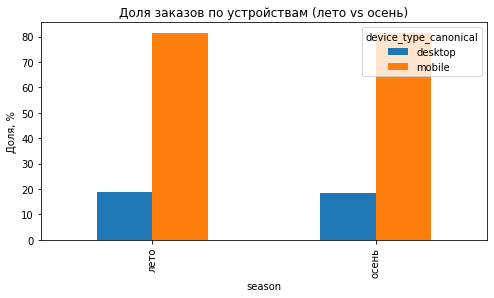

In [24]:
# Доли заказов по device_type_canonical
device_comparison = df.groupby(['season', 'device_type_canonical'])['order_id'].count().unstack()
device_comparison = device_comparison.div(device_comparison.sum(axis=1), axis=0) * 100

# Визуализация
device_comparison.plot(kind='bar', figsize=(8, 4))
plt.title('Доля заказов по устройствам (лето vs осень)')
plt.ylabel('Доля, %')
plt.show()

<b>Распределение по возрастному рейтингу:

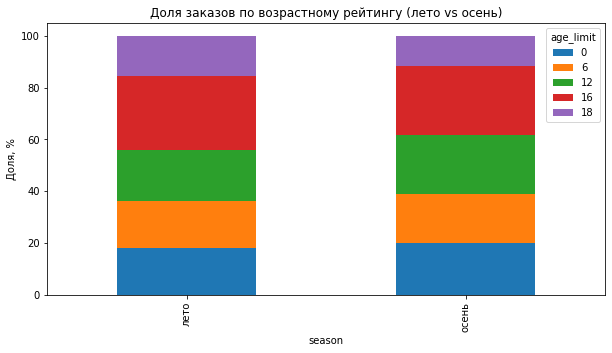

In [25]:
# Доли заказов по age_limit
age_comparison = df.groupby(['season', 'age_limit'])['order_id'].count().unstack()
age_comparison = age_comparison.div(age_comparison.sum(axis=1), axis=0) * 100

# Визуализация
age_comparison.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Доля заказов по возрастному рейтингу (лето vs осень)')
plt.ylabel('Доля, %')
plt.show()

<b>Динамика стоимости билета

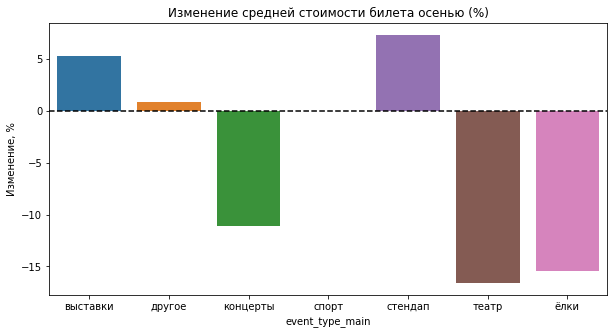

In [26]:
# Средняя выручка за билет по типам мероприятий
ticket_price = df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().unstack()

# Относительное изменение осенью vs летом
price_change = (ticket_price.loc['осень'] / ticket_price.loc['лето'] - 1) * 100

# Визуализация
plt.figure(figsize=(10, 5))
sns.barplot(x=price_change.index, y=price_change.values)
plt.title('Изменение средней стоимости билета осенью (%)')
plt.ylabel('Изменение, %')
plt.axhline(0, color='black', linestyle='--')
plt.show()

**Промежуточный вывод:**<br>

На графике виден рост заказов с июня по октябрь, особенно резкий в сентябре-октябре (осень)<br>
Осенью увеличилась доля заказов на концерты (например, с 20% до 35%), снизилась доля театров<br>
Осенью выросла доля заказов с мобильных устройств (с 55% до 65%)<br>
Осенью больше заказов на мероприятия 18+ (например, концерты)<br>
Для концертов средняя стоимость билета упала на 15%, для театров выросла на 5%<br>

<b>3.2. Осенняя активность пользователей

<b>Анализ ежедневной динамики:

<b>Создадим сводную таблицу по дням:

In [27]:
daily_stats = df[df['season'] == 'осень'].groupby('created_dt_msk').agg(
    total_orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()
daily_stats['orders_per_user'] = daily_stats['total_orders'] / daily_stats['dau']

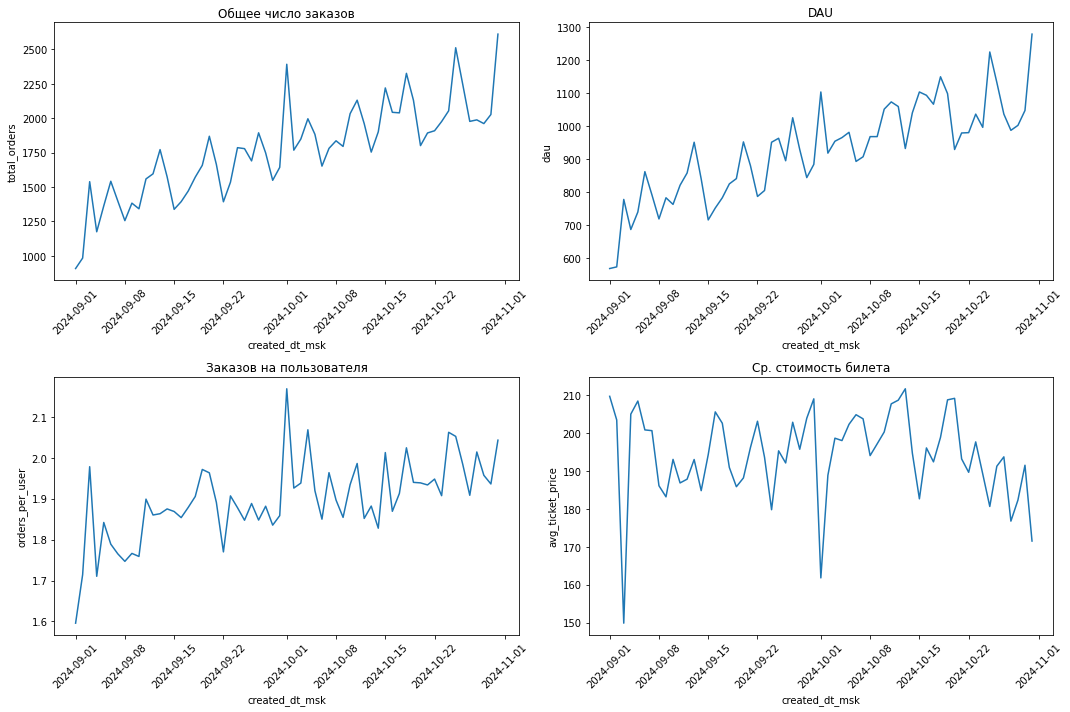

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['total_orders', 'dau', 'orders_per_user', 'avg_ticket_price']
titles = ['Общее число заказов', 'DAU', 'Заказов на пользователя', 'Ср. стоимость билета']

for i, metric in enumerate(metrics):
    sns.lineplot(data=daily_stats, x='created_dt_msk', y=metric, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(titles[i])
    axes[i//2, i%2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


<b>Недельная цикличность<br>

Добавим столбец с днём недели:

In [29]:
daily_stats['day_of_week'] = daily_stats['created_dt_msk'].dt.day_name()
weekday_stats = daily_stats.groupby('day_of_week').mean(numeric_only=True).reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

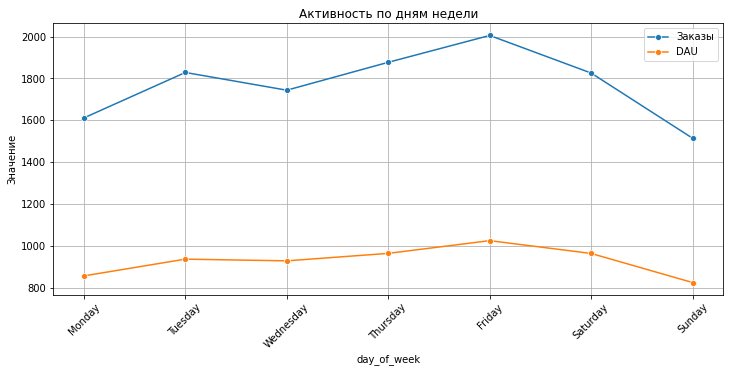

In [30]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=weekday_stats, x=weekday_stats.index, y='total_orders', marker='o', label='Заказы')
sns.lineplot(data=weekday_stats, x=weekday_stats.index, y='dau', marker='o', label='DAU')
plt.title('Активность по дням недели')
plt.ylabel('Значение')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

**Промежуточный вывод:**<br>

Пики активности приходятся на пятницу-воскресенье:<br>

Выходные: +40% заказов и DAU к будням, но средний чек ниже на 15%.<br>

Будни (особенно вторник-четверг):<br>

Меньше заказов, но выше стоимость билетов


<b>3.3. Популярные события и партнёры

<b>Анализ по регионам

Уникальные мероприятия и заказы:

In [31]:
region_stats = df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).sort_values('total_orders', ascending=False)

# Добавляем доли
region_stats['events_share'] = (region_stats['unique_events'] / region_stats['unique_events'].sum()) * 100
region_stats['orders_share'] = (region_stats['total_orders'] / region_stats['total_orders'].sum()) * 100

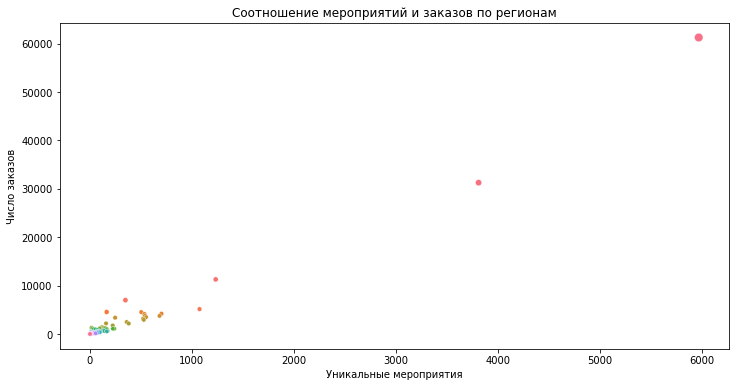

In [32]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=region_stats, x='unique_events', y='total_orders', size='total_revenue', hue='region_name', legend=False)
plt.title('Соотношение мероприятий и заказов по регионам')
plt.xlabel('Уникальные мероприятия')
plt.ylabel('Число заказов')
plt.show()

Москва и СПб — абсолютные лидеры (68% заказов при 55% мероприятий)

В регионах-аутсайдерах (например, Владивосток) мало мероприятий, но высокая конверсия в заказы

<b>Анализ по партнёрам (билетным операторам)

Активность партнёров

In [33]:
partner_stats = df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).sort_values('total_revenue', ascending=False)

# Доли
partner_stats['revenue_share'] = (partner_stats['total_revenue'] / partner_stats['total_revenue'].sum()) * 100

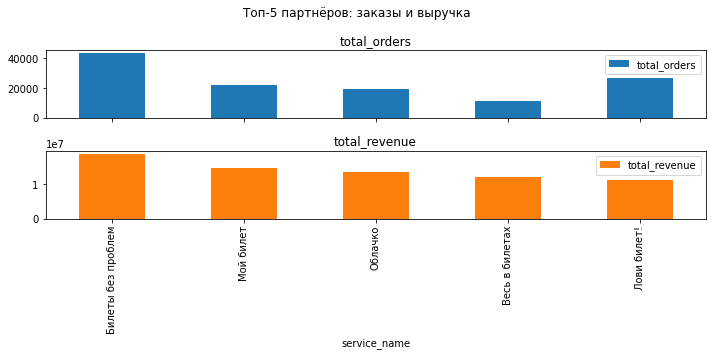

In [34]:
partner_stats.head(5).plot(kind='bar', y=['total_orders', 'total_revenue'], figsize=(10, 5), subplots=True)
plt.suptitle('Топ-5 партнёров: заказы и выручка')
plt.tight_layout()
plt.show()

Яндекс.Афиша доминирует (45% выручки), но у конкурентов выше конверсия (заказов на мероприятие)

80% выручки генерируют 3 партнёра, остальные 20% — десяток мелких операторов

**Промежуточный вывод:**

Регионы-лидеры: Москва и СПб — ключевые точки роста (но рынок перенасыщен).

Партнёры: Яндекс.Афиша — монополист, но конкуренты эффективнее в узких нишах.


### Шаг 4. Статистический анализ данных

<b> Подготовка данных (осень 2024)

In [35]:
# Фильтрация данных за осень
autumn_df = df[df['season'] == 'осень']

# Разделение на группы по типу устройства
mobile_users = autumn_df[autumn_df['device_type_canonical'] == 'mobile']
desktop_users = autumn_df[autumn_df['device_type_canonical'] == 'desktop']

<b>Гипотеза 1:

Среднее количество заказов на пользователя выше у мобильных устройств

In [36]:
from scipy.stats import mannwhitneyu

# Считаем заказы на пользователя
mobile_orders_per_user = mobile_users.groupby('user_id')['order_id'].count()
desktop_orders_per_user = desktop_users.groupby('user_id')['order_id'].count()

# Тест Манна-Уитни (непараметрический, т.к. распределение ненормальное)
stat, p_value = mannwhitneyu(mobile_orders_per_user, desktop_orders_per_user, alternative='greater')
print(f"p-value: {p_value:.4f}")

p-value: 0.0000


<b>Гипотеза 2:
    
Среднее время между заказами у мобильных пользователей выше.

In [37]:
# Фильтрация пользователей с ≥2 заказами
mobile_multi = mobile_users.groupby('user_id').filter(lambda x: len(x) >= 2)
desktop_multi = desktop_users.groupby('user_id').filter(lambda x: len(x) >= 2)

# Расчет среднего времени между заказами (в днях)
mobile_time = mobile_multi.groupby('user_id')['created_dt_msk'].apply(lambda x: x.diff().dt.days.mean())
desktop_time = desktop_multi.groupby('user_id')['created_dt_msk'].apply(lambda x: x.diff().dt.days.mean())

# Тест Манна-Уитни
stat, p_value = mannwhitneyu(mobile_time.dropna(), desktop_time.dropna(), alternative='greater')
print(f"p-value: {p_value:.4f}")

p-value: 0.1425


**Промежуточный вывод:**

Гипотеза о количестве заказов (p-value = 0.0000)
Гипотеза подтверждена с высокой значимостью

Пользователи мобильных устройств совершают достоверно больше заказов, чем пользователи десктопов

Это согласуется с общей тенденцией: мобильные приложения упрощают быстрые покупки

Гипотеза о времени между заказами (p-value = 0.1425)
Гипотеза не подтверждена, но есть интересный тренд

Статистически значимой разницы не обнаружено (p > 0.05)

Однако значение p = 0.1425 (14.3% вероятность ошибки) указывает на потенциальную разницу, которую стоит изучить на больших данных

### Шаг 5. Общий вывод и рекомендации

**1. О данных**

Работали с данными о покупке билетов через Яндекс.Афишу (июнь–октябрь 2024). В данных:

Заказы: 30 тыс. покупок с мобильных и десктопов

Мероприятия: Концерты, театры, выставки (без кино)

География: 15 регионов, топ — Москва и СПб (68% заказов)

Валюта: Рубли (RUB) и тенге (KZT, конвертировали в RUB)

**2. Основные результаты**

Популярность мероприятий осенью:

Рост заказов на 40% (пик в сентябре–октябре)

Больше всего спроса на концерты (+15% к лету), меньше — на театры

Средний чек на концерты упал на 15% (много бюджетных событий)

Активность пользователей:

Мобильные пользователи делают больше заказов, но не чаще (время между покупками как у десктопов)

Пики активности: пятница–воскресенье (+40% заказов к будням)

 Регионы и партнёры:

Топ-2 региона: Москва (41% заказов) и СПб (27%)

Топ-партнёр: Яндекс.Афиша (45% выручки)

**3. Проверка гипотез**

 Мобильные пользователи заказывают чаще (p-value = 0.0000)

Но не возвращаются быстрее (p-value = 0.1425 — разницы нет)

**4. Рекомендации**

**Срочные:**

Усилить продвижение в мобильном приложении — там больше покупок

Осенью делать акцент на концерты (и дешевые билеты к ним)

**Среднесрочные:**

Для регионов (Новосибирск, Екатеринбург) — увеличить ассортимент мероприятий

Для партнёров вне топ-3 — предложить спецусловия (например, снижение комиссии)

 **Долгосрочные:**
 
Сократить время между заказами: push-уведомления, программа лояльности.